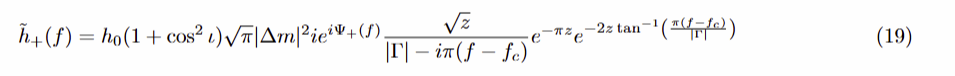

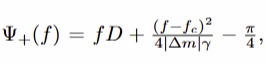

In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/GW_free_params.jl`
Precompiling project...
   6724.8 ms  ✓ GW
  1 dependency successfully precompiled in 9 seconds. 303 already precompiled.


In [2]:
using GW

In [3]:
# parameters = GenerateCatalog(100, "BBH")
parameters = ReadCatalog("catalog_BBH_n_100_Madau&Dickinson_td_10.0Myrs.h5")

Attributes: ["SFR", "date", "format", "local_rate", "number_events", "population", "seed", "time_delay_in_Myrs", "total_number_sources_yr"]
SFR: Madau&Dickinson
date: Thu 23 Oct 2025 14:21:13
format: GWJulia
local_rate: 17.0
number_events: 100
population: BBH
seed: 9084
time_delay_in_Myrs: 10.0
total_number_sources_yr: 35788
Parameters: ["Lambda1", "Lambda2", "chi1", "chi2", "dL", "eta", "iota", "mc", "phi", "phiCoal", "psi", "tcoal", "theta", "z"]


([8.716532451910089, 24.038216803624568, 60.61847132036873, 34.05945994750825, 24.339546885979285, 16.812566194029266, 16.814640425250747, 21.462430499264215, 46.34663550771297, 31.07254996286766  …  16.17941237715867, 18.444890924209812, 15.692150932149174, 48.77832628021687, 22.160585248651625, 13.418571118184687, 10.332164388937969, 24.945300476960814, 26.570848666160018, 18.94380355902224], [0.2498271936213105, 0.24597318438600024, 0.16025035045256925, 0.2061171806616087, 0.24656461522323567, 0.24999454866894988, 0.2490494563668798, 0.2495675005291848, 0.19102019661458805, 0.24999752568709196  …  0.24284194135224166, 0.24892388674524474, 0.24792536395058953, 0.22318105318146755, 0.2388343054948302, 0.24913102017340674, 0.24987519264078512, 0.24962054291600694, 0.2499982757350583, 0.24852007554091843], [-0.08513513278305587, 0.45323342701830993, -0.05446822385108222, 0.13910671915277822, 0.040304060561847654, -0.02856818361907172, 0.041143757767865205, 0.07543678203146094, 0.0655743

In [5]:
# Now test your type hierarchy:

# 1. Check if PhenomD() is a CBC type
model = BosonSR_ann()#PhenomD()
println("BosonSR_ann() isa NonCBC: ", model isa NonCBC)


BosonSR_ann() isa NonCBC: true


In [6]:

# 2. Check if PhenomD() is a GrModel type  
println("PhenomD() isa GrModel: ", model isa GrModel)

# 3. Check if PhenomD() is a Model type
println("PhenomD() isa Model: ", model isa Model)

# 4. Get the full type hierarchy
println("Type of PhenomD(): ", typeof(model))
println("Supertypes: ", supertypes(typeof(model)))

# 5. Check other models too
tiger_model = PhenomD_TIGER(2.0)
println("PhenomD_TIGER isa BgrModel: ", tiger_model isa BgrModel)
println("PhenomD_TIGER isa CBC: ", tiger_model isa CBC)
println("PhenomD_TIGER isa Model: ", tiger_model isa Model)

# 6. You can also check the abstract type hierarchy directly
println("CBC <: Model: ", CBC <: Model)
println("GrModel <: CBC: ", GrModel <: CBC) 
println("BgrModel <: CBC: ", BgrModel <: CBC)

PhenomD() isa GrModel: false
PhenomD() isa Model: true
Type of PhenomD(): BosonSR
Supertypes: (BosonSR, NonCBC, Model, Any)
PhenomD_TIGER isa BgrModel: true
PhenomD_TIGER isa CBC: true
PhenomD_TIGER isa Model: true
CBC <: Model: true
GrModel <: CBC: true
BgrModel <: CBC: true


In [ ]:
function foo(x,y)
    data = readdlm("data.txt")
    return x + y + sum(data)
end



In [6]:
M_ann_ = 3.1e-04  # in solar masses
mua_ann = 2e-16  # in GeV
sigma_M = 0.1 * M_ann_
sigma_mua = 0.1 * mua_ann
samples_M = randn(100) .* sigma_M .+ M_ann_
samples_mua = randn(100) .* sigma_mua .+ mua_ann
intrinsic_parameters = (samples_M, samples_mua)
SNR = SNR(BosonSR_ann(), [ETLS], intrinsic_parameters, parameters[5:10]...)

CompositeException: TaskFailedException

    nested task error: MethodError: no method matching PolAbs(::BosonSR_ann, ::Vector{Float64}, ::Float64, ::Float64, ::Float64, ::Float64)
    The function `PolAbs` exists, but no method is defined for this combination of argument types.
    
    Closest candidates are:
      PolAbs(::Model, ::Any, ::Any, ::Any, ::Any, ::Any, !Matched::Any, !Matched::Any)
       @ GW ~/GW_free_params.jl/src/waveforms/waveforms_master.jl:83
      PolAbs(!Matched::TaylorF2, ::AbstractVector, ::Any, ::Any, ::Any, ::Any, !Matched::Any, !Matched::Any; ...)
       @ GW ~/GW_free_params.jl/src/waveforms/TaylorF2.jl:10
      PolAbs(!Matched::TaylorF2, ::AbstractVector, ::Any, ::Any, ::Any, ::Any, !Matched::Any, !Matched::Any, !Matched::Any; ...)
       @ GW ~/GW_free_params.jl/src/waveforms/TaylorF2.jl:10
      ...
    
    Stacktrace:
     [1] SNR(model::BosonSR_ann, detector::Detector, intrinsic_param::Tuple{Float64, Float64}, dL::Float64, theta::Float64, phi::Float6